**Summary**
The purpose of this notebook is to develop our initial model using the equations from the textbook, we do this to setup the mechanics so that in the future it is easier to modify our model and include more features. 

Our goal is to simulate a glucose monitor solving the optimal control problem of keeping a person's glucose within specified bounds. To do this we set up the CGM class. The CGM class "monitors" glucose levels and dispenses insulin to lower blood sugar when it is detected to be too high. 

Future CGM iterations might have more sophisticated objective functions, be able to deliver both glucose and insulin and take time lags into account by predicting the overall blood glucose trend.

Important facts:
- CGMs have a 5-15 minute time lag
- Most CGMs only deliver insulin to lower blood sugar, but there are some that also deliver glucose to raise it.
- The model from the book is a simplified and linearized version of the Bergman minimal model.

The equations from 17.2.2 are:
\begin{align}
\dot{x}_1 &= -ax_1 - bx_2 \\
\dot{x}_2 &= -cx_2 + dx_1 + u
\end{align}
where x_1 is the glucose and x_2 is the insulin concentration and the constants are all non-negative

In [7]:
import numpy as np
import scipy.linalg
import scipy.signal
class CGM():
    def __init__(self, a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, target=83, base_insulin=10):
        # This is our target glucose measurement 
        self.target = target
        # This is the baseline amount of insulin
        self.base_insulin = base_insulin 
        # Our model will penalize the difference between the current state and these baselines

        # Define evolution matrices for AX + Bu
        A = np.array([[-a, -b], [d, -c]])
        B = np.array([[0], [1]])

        # Now we convert to a discrete system since we only sample every few minutes
        # see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html#scipy.signal.cont2discrete
        discrete_system = scipy.signal.cont2discrete((A, B, np.eye(2), np.zeros((2,1))), dt, method='zoh')
        self.A = discrete_system[0]
        self.B = discrete_system[1]
        self.Q = np.array([[glucose_penalty, 0], [0, insulin_penalty]])
        self.R = np.array([controller_penalty])
        self.K = self.fit()
    def fit(self):
        # Solves discrete algebraic riccati equations
        P = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
        return np.linalg.inv(self.R + self.B.T @ P @ self.B) @ (self.B.T @ P @ self.A)
    def control(self, current_values):
        """Given the value observed by the CGM use the objective to apply optimal control"""
        # First we calculate the errors
        glucose, insulin = current_values
        x1 = glucose - self.target
        x2 = insulin - self.base_insulin
        xk = np.array([[x1], [x2]])
        u = -self.K @ xk
        # We can't deliver negative insulin, the indexing is because u is technically a matrix
        u = max(0.0, u[0][0])
        return u

        

This class can be understood as taking a measurement every dt, calculating the best dose for that period, applying a constant dose, then remeasuring after dt time. 

In [37]:
import numpy as np
from scipy.integrate import solve_ivp
def simulate(t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, target=83, base_insulin=10):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, target, base_insulin)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    for t in range(0, t_steps, dt):
        current[0] += np.random.randint(0, 10)
        u = cgm.control(current)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)


t, states = simulate(60, 5, np.array([130, 40]), 0.02, 0.01, 0.1, 0.0, 10, 100, 1)



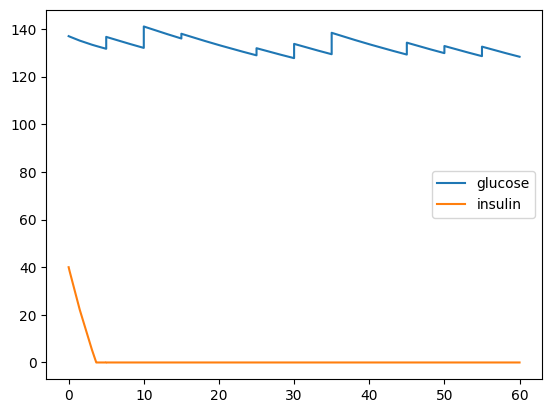

In [38]:
import matplotlib.pyplot as plt
plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()